In [1]:
library(reticulate)
library(stringr)
library(dplyr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
library(reticulate)

use_condaenv("clean_r_env", required = TRUE)

py_config()

python:         /home/nk1125/miniconda3/envs/clean_r_env/bin/python
libpython:      /home/nk1125/miniconda3/envs/clean_r_env/lib/libpython3.13.so
pythonhome:     /home/nk1125/miniconda3/envs/clean_r_env:/home/nk1125/miniconda3/envs/clean_r_env
version:        3.13.3 | packaged by conda-forge | (main, Apr 14 2025, 20:44:03) [GCC 13.3.0]
numpy:          /home/nk1125/miniconda3/envs/clean_r_env/lib/python3.13/site-packages/numpy
numpy_version:  2.4.4

NOTE: Python version was forced by use_python() function

In [3]:

py_install(c("xarray", "zarr", "numpy"), pip = TRUE)

In [4]:
py_require(c("xarray", "zarr", "numpy"))

In [5]:
xr <- import("xarray", delay_load = FALSE)

zarr_dir <- file.path("deadtree", "deadtrees_maps_v2")
zarr_paths <- list.files(zarr_dir, pattern = "_inference\\.zarr$", full.names = TRUE)


In [7]:
get_site_id <- function(zpath) str_replace(basename(zpath), "_inference\\.zarr$", "")

all_results <- list()

for (zpath in zarr_paths) {

  site_id <- get_site_id(zpath)
  message("Processing ", site_id)

  ds <- xr$open_zarr(zpath, consolidated = FALSE)

  years <- as.integer(py_to_r(ds[["time"]]$values))
  x <- as.vector(py_to_r(ds[["x"]]$values))
  y <- as.vector(py_to_r(ds[["y"]]$values))

  # 500 m mask around cube center
  x0 <- mean(range(x))
  y0 <- mean(range(y))
  dist2 <- outer((y - y0)^2, (x - x0)^2, "+")
  mask <- dist2 <= (500^2)

  # load forest as R array and convert to %
  # dimensions should be [time, y, x]
  forest_arr <- py_to_r(ds[["forest"]]$values)
  forest_arr <- array(as.numeric(forest_arr) * (100 / 255), dim = dim(forest_arr))

  out_list <- vector("list", length(years))

  for (i in seq_along(years)) {

    forest_now <- forest_arr[i, , ]
    forest_mean_pct_500m <- mean(forest_now[mask], na.rm = TRUE)

    if (i == 1) {
      loss_area_frac_500m <- NA_real_
      loss_mean_pp_500m   <- NA_real_
      loss_sum_pp_500m    <- NA_real_
    } else {
      forest_prev <- forest_arr[i - 1, , ]

      # year-to-year change
      delta <- forest_now - forest_prev

      # thresholded loss: drop greater than 20 percentage points
      loss_pp <- ifelse(delta <= -20, -delta, 0)

      # metrics inside 500 m mask
      masked_loss <- loss_pp[mask]

      loss_area_frac_500m <- mean(masked_loss > 0, na.rm = TRUE)
      loss_mean_pp_500m   <- mean(masked_loss, na.rm = TRUE)
      loss_sum_pp_500m    <- sum(masked_loss, na.rm = TRUE)
    }

    out_list[[i]] <- data.frame(
      site_id = site_id,
      year = years[i],
      forest_mean_pct_500m = forest_mean_pct_500m,
      loss_area_frac_500m = loss_area_frac_500m,
      loss_mean_pp_500m = loss_mean_pp_500m,
      loss_sum_pp_500m = loss_sum_pp_500m
    )
  }

  all_results[[site_id]] <- bind_rows(out_list)
}


Processing AR-SLu

Processing AR-Vir

Processing AT-Neu

Processing AU-Boy

Processing AU-Emr

Processing AU-Gin

Processing AU-GWW

Processing AU-Lon

Processing AU-Rgf

Processing AU-Rig

Processing AU-Rob

Processing AU-Wac

Processing AU-War

Processing AU-Whr

Processing AU-Wom

Processing AU-Ync

Processing BR-CST

Processing BR-Npw

Processing BR-Sa3

Processing CA-Ca1

Processing CA-Ca2

Processing CA-Cbo

Processing CA-CF1

Processing CA-DB2

Processing CA-EM1

Processing CA-Gro

Processing CA-LP1

Processing CA-MA2

Processing CA-MA3

Processing CA-Man

Processing CA-NS1

Processing CA-NS2

Processing CA-NS3

Processing CA-NS4

Processing CA-NS5

Processing CA-NS6

Processing CA-NS7

Processing CA-Oas

Processing CA-Qc2

Processing CA-Qfo

Processing CA-SF1

Processing CA-SF2

Processing CA-SF3

Processing CA-TP2

Processing CA-TP3

Processing CA-TP4

Processing CA-TPD

Processing CG-Tch

Processing CH-Cha

Processing CH-Fru

Processing CL-SDF

Processing CN-Cha

Processing C

In [6]:

# helper
get_site_id <- function(zpath) str_replace(basename(zpath), "_inference\\.zarr$", "")

all_results <- list()

for (zpath in zarr_paths) {
  
  site_id <- get_site_id(zpath)
  message("Processing ", site_id)
  
  ds <- xr$open_zarr(zpath, consolidated = FALSE)
  
  years <- as.integer(py_to_r(ds[["time"]]$values))
  x <- as.vector(py_to_r(ds[["x"]]$values))
  y <- as.vector(py_to_r(ds[["y"]]$values))
  
  # 500 m mask around cube center
  x0 <- mean(range(x))
  y0 <- mean(range(y))
  dist2 <- outer((y - y0)^2, (x - x0)^2, "+")
  mask <- dist2 <= (500^2)
  
  # ------------------------------------------------------
  # Load forest and deadwood arrays and convert to %
  # expected dimensions: [time, y, x]
  # ------------------------------------------------------
  
  forest_arr <- py_to_r(ds[["forest"]]$values)
  forest_arr <- array(as.numeric(forest_arr) * (100 / 255), dim = dim(forest_arr))
  
  deadwood_arr <- py_to_r(ds[["deadwood"]]$values)
  deadwood_arr <- array(as.numeric(deadwood_arr) * (100 / 255), dim = dim(deadwood_arr))
  
  out_list <- vector("list", length(years))
  
  for (i in seq_along(years)) {
    
    forest_now <- forest_arr[i, , ]
    deadwood_now <- deadwood_arr[i, , ]
    
    # mean state inside 500 m
    forest_mean_pct_500m <- mean(forest_now[mask], na.rm = TRUE)
    deadwood_mean_pct_500m <- mean(deadwood_now[mask], na.rm = TRUE)
    
    if (i == 1) {
      
      # forest threshold metrics
      loss_area_frac_500m <- NA_real_
      loss_mean_pp_500m   <- NA_real_
      loss_sum_pp_500m    <- NA_real_
      
      # deadwood threshold metrics
      deadwood_increase_area_frac_500m <- NA_real_
      deadwood_increase_mean_pp_500m   <- NA_real_
      deadwood_increase_sum_pp_500m    <- NA_real_
      
    } else {
      
      forest_prev <- forest_arr[i - 1, , ]
      deadwood_prev <- deadwood_arr[i - 1, , ]
      
      # --------------------------------------------------
      # FOREST: thresholded loss (>20 percentage-point drop)
      # --------------------------------------------------
      forest_delta <- forest_now - forest_prev
      
      # keep only drops <= -20 pp, convert to positive magnitude
      loss_pp <- ifelse(forest_delta <= -20, -forest_delta, 0)
      
      masked_loss <- loss_pp[mask]
      
      loss_area_frac_500m <- mean(masked_loss > 0, na.rm = TRUE)
      loss_mean_pp_500m   <- mean(masked_loss, na.rm = TRUE)
      loss_sum_pp_500m    <- sum(masked_loss, na.rm = TRUE)
      
      # --------------------------------------------------
      # DEADWOOD: thresholded increase (>20 percentage-point gain)
      # --------------------------------------------------
      deadwood_delta <- deadwood_now - deadwood_prev
      
      # keep only increases >= 20 pp
      deadwood_gain_pp <- ifelse(deadwood_delta >= 20, deadwood_delta, 0)
      
      masked_deadwood_gain <- deadwood_gain_pp[mask]
      
      deadwood_increase_area_frac_500m <- mean(masked_deadwood_gain > 0, na.rm = TRUE)
      deadwood_increase_mean_pp_500m   <- mean(masked_deadwood_gain, na.rm = TRUE)
      deadwood_increase_sum_pp_500m    <- sum(masked_deadwood_gain, na.rm = TRUE)
    }
    
    out_list[[i]] <- data.frame(
      site_id = site_id,
      year = years[i],
      
      forest_mean_pct_500m = forest_mean_pct_500m,
      loss_area_frac_500m = loss_area_frac_500m,
      loss_mean_pp_500m = loss_mean_pp_500m,
      loss_sum_pp_500m = loss_sum_pp_500m,
      
      deadwood_mean_pct_500m = deadwood_mean_pct_500m,
      deadwood_increase_area_frac_500m = deadwood_increase_area_frac_500m,
      deadwood_increase_mean_pp_500m = deadwood_increase_mean_pp_500m,
      deadwood_increase_sum_pp_500m = deadwood_increase_sum_pp_500m
    )
  }
  
  all_results[[site_id]] <- bind_rows(out_list)
}

final_disturbance_df <- bind_rows(all_results)

Processing AR-SLu

Processing AR-Vir

Processing AT-Neu

Processing AU-Boy

Processing AU-Emr

Processing AU-Gin

Processing AU-GWW

Processing AU-Lon

Processing AU-Rgf

Processing AU-Rig

Processing AU-Rob

Processing AU-Wac

Processing AU-War

Processing AU-Whr

Processing AU-Wom

Processing AU-Ync

Processing BR-CST

Processing BR-Npw

Processing BR-Sa3

Processing CA-Ca1

Processing CA-Ca2

Processing CA-Cbo

Processing CA-CF1

Processing CA-DB2

Processing CA-EM1

Processing CA-Gro

Processing CA-LP1

Processing CA-MA2

Processing CA-MA3

Processing CA-Man

Processing CA-NS1

Processing CA-NS2

Processing CA-NS3

Processing CA-NS4

Processing CA-NS5

Processing CA-NS6

Processing CA-NS7

Processing CA-Oas

Processing CA-Qc2

Processing CA-Qfo

Processing CA-SF1

Processing CA-SF2

Processing CA-SF3

Processing CA-TP2

Processing CA-TP3

Processing CA-TP4

Processing CA-TPD

Processing CG-Tch

Processing CH-Cha

Processing CH-Fru

Processing CL-SDF

Processing CN-Cha

Processing C

In [11]:
### different buffer sizes
library(dplyr)
library(stringr)

get_site_id <- function(zpath) {
  str_replace(basename(zpath), "_inference\\.zarr$", "")
}

# radii in meters
buffer_radii <- c(100, 200, 300, 400, 500)

all_results <- list()

for (zpath in zarr_paths) {
  
  site_id <- get_site_id(zpath)
  message("Processing ", site_id)
  
  ds <- xr$open_zarr(zpath, consolidated = FALSE)
  
  years <- as.integer(py_to_r(ds[["time"]]$values))
  x <- as.vector(py_to_r(ds[["x"]]$values))
  y <- as.vector(py_to_r(ds[["y"]]$values))
  
  # ------------------------------------------------------
  # Build distance grid from cube center
  # ------------------------------------------------------
  
  x0 <- mean(range(x))
  y0 <- mean(range(y))
  dist2 <- outer((y - y0)^2, (x - x0)^2, "+")
  
  # one mask per radius
  mask_list <- lapply(buffer_radii, function(r) dist2 <= (r^2))
  names(mask_list) <- paste0(buffer_radii, "m")
  
  # ------------------------------------------------------
  # Load forest and deadwood arrays and convert to %
  # expected dimensions: [time, y, x]
  # ------------------------------------------------------
  
  forest_arr <- py_to_r(ds[["forest"]]$values)
  forest_arr <- array(as.numeric(forest_arr) * (100 / 255), dim = dim(forest_arr))
  
  deadwood_arr <- py_to_r(ds[["deadwood"]]$values)
  deadwood_arr <- array(as.numeric(deadwood_arr) * (100 / 255), dim = dim(deadwood_arr))
  
  out_list <- vector("list", length(years))
  
  for (i in seq_along(years)) {
    
    forest_now <- forest_arr[i, , ]
    deadwood_now <- deadwood_arr[i, , ]
    
    row_out <- list(
      site_id = site_id,
      year = years[i]
    )
    
    if (i > 1) {
      forest_prev <- forest_arr[i - 1, , ]
      deadwood_prev <- deadwood_arr[i - 1, , ]
      
      # year-to-year changes
      forest_delta <- forest_now - forest_prev
      deadwood_delta <- deadwood_now - deadwood_prev
      
      # thresholded changes
      # FOREST: keep only drops <= -20 pp, convert to positive magnitude
      loss_pp <- ifelse(forest_delta <= -20, -forest_delta, 0)
      
      # DEADWOOD: keep only increases >= 20 pp
      deadwood_gain_pp <- ifelse(deadwood_delta >= 20, deadwood_delta, 0)
    }
    
    # ----------------------------------------------------
    # Calculate metrics for each buffer radius
    # ----------------------------------------------------
    
    for (r in buffer_radii) {
      
      rlab <- paste0(r, "m")
      mask <- mask_list[[rlab]]
      
      # mean state
      row_out[[paste0("forest_mean_pct_", rlab)]] <- mean(forest_now[mask], na.rm = TRUE)
      row_out[[paste0("deadwood_mean_pct_", rlab)]] <- mean(deadwood_now[mask], na.rm = TRUE)
      
      if (i == 1) {
        # no previous year available
        row_out[[paste0("loss_area_frac_", rlab)]] <- NA_real_
        row_out[[paste0("loss_mean_pp_", rlab)]]   <- NA_real_
        row_out[[paste0("loss_sum_pp_", rlab)]]    <- NA_real_
        
        row_out[[paste0("deadwood_increase_area_frac_", rlab)]] <- NA_real_
        row_out[[paste0("deadwood_increase_mean_pp_", rlab)]]   <- NA_real_
        row_out[[paste0("deadwood_increase_sum_pp_", rlab)]]    <- NA_real_
        
      } else {
        masked_loss <- loss_pp[mask]
        masked_deadwood_gain <- deadwood_gain_pp[mask]
        
        # forest loss metrics
        row_out[[paste0("loss_area_frac_", rlab)]] <- mean(masked_loss > 0, na.rm = TRUE)
        row_out[[paste0("loss_mean_pp_", rlab)]]   <- mean(masked_loss, na.rm = TRUE)
        row_out[[paste0("loss_sum_pp_", rlab)]]    <- sum(masked_loss, na.rm = TRUE)
        
        # deadwood increase metrics
        row_out[[paste0("deadwood_increase_area_frac_", rlab)]] <- mean(masked_deadwood_gain > 0, na.rm = TRUE)
        row_out[[paste0("deadwood_increase_mean_pp_", rlab)]]   <- mean(masked_deadwood_gain, na.rm = TRUE)
        row_out[[paste0("deadwood_increase_sum_pp_", rlab)]]    <- sum(masked_deadwood_gain, na.rm = TRUE)
      }
    }
    
    out_list[[i]] <- as.data.frame(row_out, check.names = FALSE)
  }
  
  all_results[[site_id]] <- bind_rows(out_list)
}

final_disturbance_df <- bind_rows(all_results)

Processing AR-SLu

Processing AR-Vir

Processing AT-Neu

Processing AU-Boy

Processing AU-Emr

Processing AU-Gin

Processing AU-GWW

Processing AU-Lon

Processing AU-Rgf

Processing AU-Rig

Processing AU-Rob

Processing AU-Wac

Processing AU-War

Processing AU-Whr

Processing AU-Wom

Processing AU-Ync

Processing BR-CST

Processing BR-Npw

Processing BR-Sa3

Processing CA-Ca1

Processing CA-Ca2

Processing CA-Cbo

Processing CA-CF1

Processing CA-DB2

Processing CA-EM1

Processing CA-Gro

Processing CA-LP1

Processing CA-MA2

Processing CA-MA3

Processing CA-Man

Processing CA-NS1

Processing CA-NS2

Processing CA-NS3

Processing CA-NS4

Processing CA-NS5

Processing CA-NS6

Processing CA-NS7

Processing CA-Oas

Processing CA-Qc2

Processing CA-Qfo

Processing CA-SF1

Processing CA-SF2

Processing CA-SF3

Processing CA-TP2

Processing CA-TP3

Processing CA-TP4

Processing CA-TPD

Processing CG-Tch

Processing CH-Cha

Processing CH-Fru

Processing CL-SDF

Processing CN-Cha

Processing C

ERROR: [Errno 112] Host is down: '/mnt/gsdata/projects/panops/panops-data-registry/data/flux/deadtree/sentinelcubes/US-WPT_inference.zarr/time/c/0'

In [ ]:
library(reticulate)
library(dplyr)
library(stringr)

py_require(c("xarray", "zarr", "numpy"))
xr <- import("xarray", delay_load = FALSE)

zarr_dir <- file.path("deadtree", "deadtrees_maps_v2")
zarr_paths <- list.files(zarr_dir, pattern = "_inference\\.zarr$", full.names = TRUE)

get_site_id <- function(zpath) {
  str_replace(basename(zpath), "_inference\\.zarr$", "")
}

buffer_radii <- c(100, 200, 300, 400, 500)

all_results <- list()

for (zpath in zarr_paths) {
  
  site_id <- get_site_id(zpath)
  message("Processing ", site_id)
  
  ds <- xr$open_zarr(zpath, consolidated = FALSE)
  
  years <- as.integer(py_to_r(ds[["time"]]$values))
  x <- as.vector(py_to_r(ds[["x"]]$values))
  y <- as.vector(py_to_r(ds[["y"]]$values))
  
  x0 <- mean(range(x))
  y0 <- mean(range(y))
  dist2 <- outer((y - y0)^2, (x - x0)^2, "+")
  
  mask_list <- lapply(buffer_radii, function(r) dist2 <= (r^2))
  names(mask_list) <- paste0(buffer_radii, "m")
  
  # main variables: 0–255 converted to %
  forest_arr <- py_to_r(ds[["forest"]]$values)
  forest_arr <- array(as.numeric(forest_arr) * (100 / 255), dim = dim(forest_arr))
  
  deadwood_arr <- py_to_r(ds[["deadwood"]]$values)
  deadwood_arr <- array(as.numeric(deadwood_arr) * (100 / 255), dim = dim(deadwood_arr))
  
  out_list <- vector("list", length(years))
  
  for (i in seq_along(years)) {
    
    forest_now <- forest_arr[i, , ]
    deadwood_now <- deadwood_arr[i, , ]
    
    row_out <- list(
      site_id = site_id,
      year = years[i]
    )
    
    if (i > 1) {
      forest_prev <- forest_arr[i - 1, , ]
      deadwood_prev <- deadwood_arr[i - 1, , ]
      
      forest_delta <- forest_now - forest_prev
      deadwood_delta <- deadwood_now - deadwood_prev
      
      # thresholded forest loss: loss greater than 20 percentage points
      loss_pp <- ifelse(forest_delta <= -20, -forest_delta, 0)
      
      # thresholded deadwood increase: increase greater than 20 percentage points
      deadwood_gain_pp <- ifelse(deadwood_delta >= 20, deadwood_delta, 0)
    }
    
    for (r in buffer_radii) {
      
      rlab <- paste0(r, "m")
      mask <- mask_list[[rlab]]
      
      forest_mean <- mean(forest_now[mask], na.rm = TRUE)
      deadwood_mean <- mean(deadwood_now[mask], na.rm = TRUE)
      
      row_out[[paste0("forest_mean_pct_", rlab)]] <- forest_mean
      row_out[[paste0("deadwood_mean_pct_", rlab)]] <- deadwood_mean
      
      # NEW: mortality intensity
      # deadwood as percentage of forest cover
      row_out[[paste0("mortality_intensity_pct_", rlab)]] <- ifelse(
        forest_mean > 0,
        deadwood_mean / forest_mean * 100,
        NA_real_
      )
      
      # optional capped version, useful because model can slightly violate deadwood <= forest
      row_out[[paste0("mortality_intensity_pct_capped_", rlab)]] <- ifelse(
        forest_mean > 0,
        pmin(deadwood_mean / forest_mean * 100, 100),
        NA_real_
      )
      
      if (i == 1) {
        
        row_out[[paste0("loss_area_frac_", rlab)]] <- NA_real_
        row_out[[paste0("loss_mean_pp_", rlab)]]   <- NA_real_
        row_out[[paste0("loss_sum_pp_", rlab)]]    <- NA_real_
        
        row_out[[paste0("deadwood_increase_area_frac_", rlab)]] <- NA_real_
        row_out[[paste0("deadwood_increase_mean_pp_", rlab)]]   <- NA_real_
        row_out[[paste0("deadwood_increase_sum_pp_", rlab)]]    <- NA_real_
        
      } else {
        
        masked_loss <- loss_pp[mask]
        masked_deadwood_gain <- deadwood_gain_pp[mask]
        
        row_out[[paste0("loss_area_frac_", rlab)]] <- mean(masked_loss > 0, na.rm = TRUE)
        row_out[[paste0("loss_mean_pp_", rlab)]]   <- mean(masked_loss, na.rm = TRUE)
        row_out[[paste0("loss_sum_pp_", rlab)]]    <- sum(masked_loss, na.rm = TRUE)
        
        row_out[[paste0("deadwood_increase_area_frac_", rlab)]] <- mean(masked_deadwood_gain > 0, na.rm = TRUE)
        row_out[[paste0("deadwood_increase_mean_pp_", rlab)]]   <- mean(masked_deadwood_gain, na.rm = TRUE)
        row_out[[paste0("deadwood_increase_sum_pp_", rlab)]]    <- sum(masked_deadwood_gain, na.rm = TRUE)
      }
    }
    
    out_list[[i]] <- as.data.frame(row_out, check.names = FALSE)
  }
  
  all_results[[site_id]] <- bind_rows(out_list)
}

final_disturbance_df <- bind_rows(all_results)

write.csv(
  final_disturbance_df,
  "derived_tables/final_disturbance_v2_multibuffer_with_mortality_intensity.csv",
  row.names = FALSE
)

Processing AR-TF1

Processing AR-TF2

Processing AT-Mmg

Processing AT-Nsd

Processing AT-PsM

Processing AT-Zoe

Processing AU-APL

Processing AU-ASM

Processing AU-Boy

Processing AU-Col

Processing AU-Cow

Processing AU-Cpr

Processing AU-Ctr

Processing AU-Cum

Processing AU-DaS

Processing AU-Dry

Processing AU-Fle

Processing AU-Gin

Processing AU-GWW

Processing AU-How

Processing AU-Lit

Processing AU-Rob

Processing AU-Sno

Processing AU-TTE

Processing AU-Tum

Processing AU-Whr

Processing AU-Wom

Processing AU-Wrr

Processing BE-Bra

Processing BE-Lcr

Processing BE-Maa

Processing BE-Vie

Processing BJ-Bfg

Processing BJ-Nhu

Processing BR-ITA

Processing BR-Npw

Processing BW-Gum

Processing CA-ARB

Processing CA-ARF

Processing CA-BOU

Processing CA-Ca3

Processing CA-CF3

Processing CA-DB2

Processing CA-DBB

Processing CA-DSM

Processing CA-EM1

Processing CA-EM2

Processing CA-HPC

Processing CA-KLP

Processing CA-LP1

Processing CA-LU1

Processing CA-LU2

Processing C

In [12]:
save.image("partial_workspace_after_hostdown.RData")

In [13]:
exists("all_results")
length(all_results)
names(all_results)[1:10]
tail(names(all_results), 10)

[1] TRUE

[1] 307

[1] "AR-SLu" "AR-Vir" "AT-Neu" "AU-Boy" "AU-Emr" "AU-Gin" "AU-GWW" "AU-Lon"
 [9] "AU-Rgf" "AU-Rig"

[1] "US-Wi2" "US-Wi3" "US-Wi4" "US-Wi5" "US-Wi6" "US-Wi7" "US-Wi8" "US-Wi9"
 [9] "US-Wjs" "US-Wkg"

In [7]:
write.csv(final_disturbance_df,
          "derived_tables/forest_loss_deadwood_threshold20_500m_by_site_year.csv",
          row.names = FALSE)

In [21]:
View(final_disturbance_df)

site_id,year,forest_mean_pct_100m,deadwood_mean_pct_100m,mortality_intensity_pct_100m,mortality_intensity_pct_capped_100m,loss_area_frac_100m,loss_mean_pp_100m,loss_sum_pp_100m,deadwood_increase_area_frac_100m,⋯,forest_mean_pct_500m,deadwood_mean_pct_500m,mortality_intensity_pct_500m,mortality_intensity_pct_capped_500m,loss_area_frac_500m,loss_mean_pp_500m,loss_sum_pp_500m,deadwood_increase_area_frac_500m,deadwood_increase_mean_pp_500m,deadwood_increase_sum_pp_500m
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR-TF1,2016,33.039216,2.16182676,6.5432145,6.5432145,NA,NA,NA,NA,⋯,46.92326,11.446390,24.393849,24.393849,NA,NA,NA,NA,NA,NA
AR-TF1,2017,34.159841,8.87937453,25.9936060,25.9936060,0.003164557,0.06329114,20.0000,0,⋯,41.02205,15.469091,37.709209,37.709209,0.0936386768,2.245971162,17653.33333,0.0296437659,0.708875917,5571.76471
AR-TF1,2018,38.354430,5.82030280,15.1750469,15.1750469,0.000000000,0.00000000,0.0000,0,⋯,43.91723,13.531657,30.811728,30.811728,0.0013994911,0.032679739,256.86275,0.0019083969,0.042708177,335.68627
AR-TF1,2019,32.956069,0.38719285,1.1748757,1.1748757,0.000000000,0.00000000,0.0000,0,⋯,40.22247,7.975253,19.827855,19.827855,0.0038167939,0.083470538,656.07843,0.0040712468,0.135758120,1067.05882
AR-TF1,2020,33.818565,2.63216679,7.7832006,7.7832006,0.000000000,0.00000000,0.0000,0,⋯,40.47453,9.187497,22.699453,22.699453,0.0015267176,0.037519333,294.90196,0.0016539440,0.038118046,299.60784
AR-TF1,2021,57.325639,0.02482005,0.0432966,0.0432966,0.000000000,0.00000000,0.0000,0,⋯,50.44484,4.645013,9.208103,9.208103,0.0007633588,0.022002694,172.94118,0.0000000000,0.000000000,0.00000
AR-TF1,2022,47.596178,0.00000000,0.0000000,0.0000000,0.000000000,0.00000000,0.0000,0,⋯,44.15567,6.032530,13.661962,13.661962,0.0007633588,0.016564387,130.19608,0.0001272265,0.002893778,22.74510
AR-TF1,2023,39.137503,0.36857781,0.9417510,0.9417510,0.000000000,0.00000000,0.0000,0,⋯,42.90366,9.003043,20.984326,20.984326,0.0000000000,0.000000000,0.00000,0.0095419847,0.226712568,1781.96078
AR-TF1,2024,29.977662,0.00000000,0.0000000,0.0000000,0.000000000,0.00000000,0.0000,0,⋯,34.18665,6.438308,18.832813,18.832813,0.0021628499,0.046300454,363.92157,0.0001272265,0.002544529,20.00000


In [8]:
results_loss_df <- bind_rows(all_results)


In [9]:
View(results_loss_df)

site_id,year,forest_mean_pct_500m,loss_area_frac_500m,loss_mean_pp_500m,loss_sum_pp_500m
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
AR-SLu,2016,0.2881305,NA,NA,NA
AR-SLu,2017,12.3927057,0.0000000000,0.000000000,0.00000
AR-SLu,2018,9.4717857,0.0000000000,0.000000000,0.00000
AR-SLu,2019,4.8412413,0.0001272265,0.002793993,21.96078
AR-SLu,2020,4.9443696,0.0000000000,0.000000000,0.00000
AR-SLu,2021,7.9149828,0.0000000000,0.000000000,0.00000
AR-SLu,2022,3.8991169,0.0000000000,0.000000000,0.00000
AR-SLu,2023,4.3549369,0.0000000000,0.000000000,0.00000
AR-SLu,2024,3.8458814,0.0000000000,0.000000000,0.00000


In [47]:
write.csv(results_loss_df,
          "derived_tables/forest_loss_threshold20_500m_by_site_year.csv",
          row.names = FALSE)

In [10]:
library(ggplot2)


In [6]:
# choose one zarr file
zpath <- zarr_paths[1]
site_id <- str_replace(basename(zpath), "_inference\\.zarr$", "")

ds <- xr$open_zarr(zpath, consolidated = FALSE)


In [7]:
# available years
years <- as.integer(py_to_r(ds[["time"]]$values))
print(years)


[1] 2016 2017 2018 2019 2020 2021 2022 2023 2024


In [8]:
# choose one year
year_sel <- 2020
i <- which(years == year_sel)

In [9]:
# coordinates
x <- as.vector(py_to_r(ds[["x"]]$values))
y <- as.vector(py_to_r(ds[["y"]]$values))

In [10]:
# forest layer for that year, convert 0-255 -> 0-100%
forest_arr <- py_to_r(ds[["forest"]]$values)
forest_mat <- forest_arr[i, , ] * (100 / 255)


In [11]:
image(
  x = x,
  y = y,
  z = t(forest_mat[nrow(forest_mat):1, ]),
  col = hcl.colors(100, "YlGn"),
  xlab = "UTM x (m)",
  ylab = "UTM y (m)",
  main = paste("Forest cover for", site_id, "in", year_sel)
)

# add 500 m buffer
x0 <- mean(range(x))
y0 <- mean(range(y))
theta <- seq(0, 2*pi, length.out = 300)
lines(x0 + 500*cos(theta), y0 + 500*sin(theta), lwd = 2)

# add cube center
points(x0, y0, pch = 16, cex = 1.2)

ERROR: Error in image.default(x = x, y = y, z = t(forest_mat[nrow(forest_mat):1, : increasing 'x' and 'y' values expected


In [28]:
install.packages("fields")

Installing package into ‘/home/nk1125/R/library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘dotCall64’, ‘spam’




In [12]:
library(viridis)
library(RColorBrewer)

Loading required package: viridisLite



Warning message in plot.window(...):
“"legend.lab" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"legend.lab" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"legend.lab" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"legend.lab" is not a graphical parameter”
Warning message in box(...):
“"legend.lab" is not a graphical parameter”
Warning message in title(...):
“"legend.lab" is not a graphical parameter”


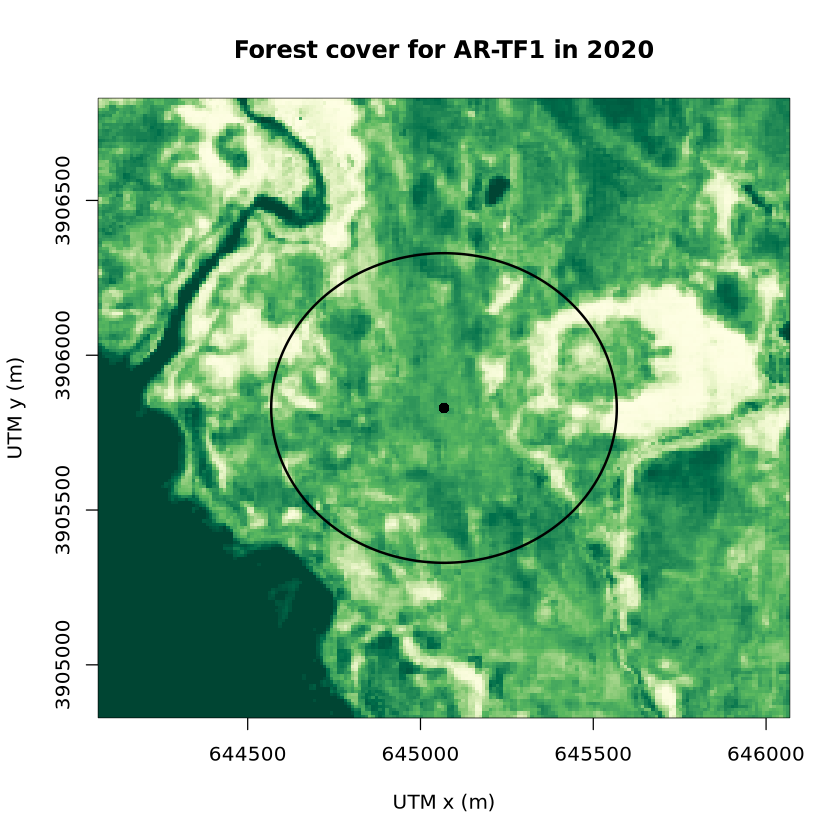

In [15]:
library(fields)
# choose one site and one year
zpath <- zarr_paths[1]
site_id <- str_replace(basename(zpath), "_inference\\.zarr$", "")

ds <- xr$open_zarr(zpath, consolidated = FALSE)

years <- as.integer(py_to_r(ds[["time"]]$values))
year_sel <- 2020
i <- which(years == year_sel)

x <- as.vector(py_to_r(ds[["x"]]$values))
y <- as.vector(py_to_r(ds[["y"]]$values))
## here we can replace "forest" with "deadwood"
forest_arr <- py_to_r(ds[["forest"]]$values)
forest_mat <- forest_arr[i, , ] * (100 / 255)

# sort coordinates so image() is happy
ix <- order(x)
iy <- order(y)

x_sorted <- x[ix]
y_sorted <- y[iy]

forest_mat_sorted <- forest_mat[iy, ix]

image(
  x = x_sorted,
  y = y_sorted,
  z = t(forest_mat_sorted),
  col = hcl.colors(100, "YlGn"),
  xlab = "UTM x (m)",
  ylab = "UTM y (m)",
  main = paste("Forest cover for", site_id, "in", year_sel),
  legend.lab = "Forest cover (%)"
)

# add 500 m buffer
x0 <- mean(range(x))
y0 <- mean(range(y))
theta <- seq(0, 2*pi, length.out = 300)
lines(x0 + 500*cos(theta), y0 + 500*sin(theta), lwd = 2)

# add cube center
points(x0, y0, pch = 16, cex = 1.2)

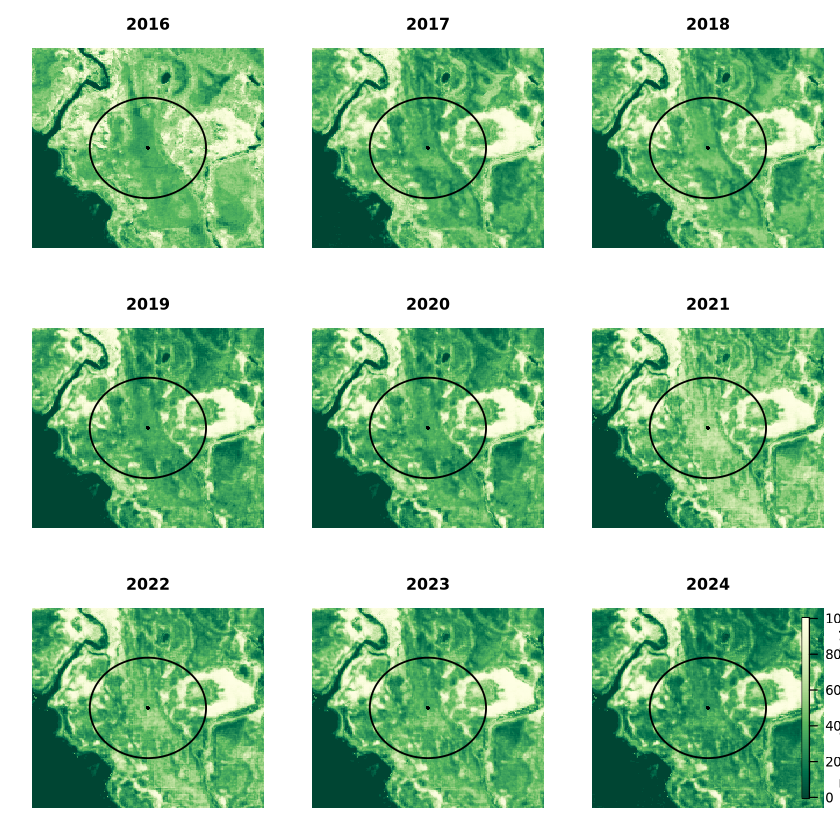

In [16]:

years <- as.integer(py_to_r(ds[["time"]]$values))
forest_arr <- py_to_r(ds[["forest"]]$values)

par(mfrow = c(3,3), mar = c(2,2,3,1))  # layout for 10 panels

for(i in seq_along(years)) {

  forest_mat <- forest_arr[i,,] * (100/255)

  # reorder matrix (needed for image)
  forest_mat_sorted <- forest_mat[iy, ix]

  image(
    x_sorted,
    y_sorted,
    t(forest_mat_sorted),
    col = hcl.colors(100, "YlGn"),
    axes = FALSE,
    main = years[i]
  )

  # 500 m buffer
  lines(x0 + 500*cos(theta), y0 + 500*sin(theta), lwd = 1.5)

  # tower / cube center
  points(x0, y0, pch = 16, cex = 0.7)
}

fields::image.plot(
  legend.only = TRUE,
  zlim = c(0,100),
  col = hcl.colors(100, "YlGn"),
  legend.lab = "Forest cover (%)",
  legend.line = 2
)

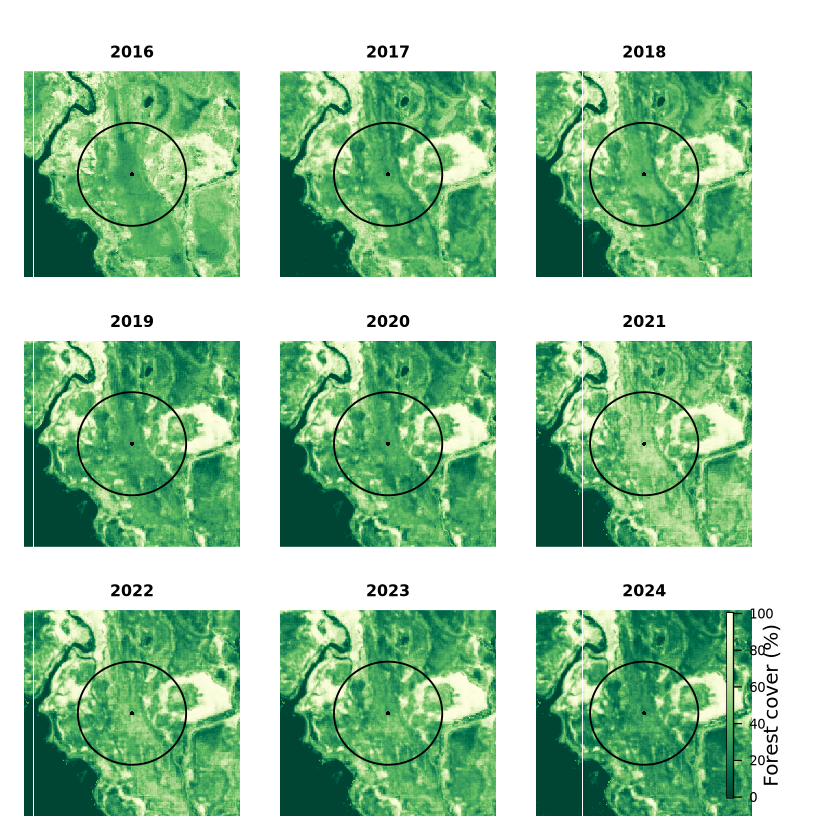

In [17]:
library(fields)

years <- as.integer(py_to_r(ds[["time"]]$values))
forest_arr <- py_to_r(ds[["forest"]]$values)

n_years <- length(years)

# layout: one column for legend
lay <- cbind(matrix(1:n_years, nrow = 3, byrow = TRUE),
             rep(n_years + 1, 3))

layout(lay, widths = c(1, 1, 1, 0.28))
par(oma = c(0, 0, 2, 0))  # optional outer margin

# ---- maps
for(i in seq_along(years)) {

  par(mar = c(1.5, 1.5, 2.5, 1))

  forest_mat <- forest_arr[i,,] * (100 / 255)
  forest_mat_sorted <- forest_mat[iy, ix]

  image(
    x_sorted,
    y_sorted,
    t(forest_mat_sorted),
    col = hcl.colors(100, "YlGn"),
    zlim = c(0, 100),
    axes = FALSE,
    xlab = "",
    ylab = "",
    main = years[i]
  )

  # 500 m buffer
  lines(x0 + 500*cos(theta), y0 + 500*sin(theta), lwd = 1.5)

  # tower / cube center
  points(x0, y0, pch = 16, cex = 0.7)
}

# ---- one shared legend
par(mar = c(2, 2, 2, 4))
fields::image.plot(
  legend.only = TRUE,
  zlim = c(0, 100),
  col = hcl.colors(100, "YlGn"),
  legend.lab = "Forest cover (%)"
)

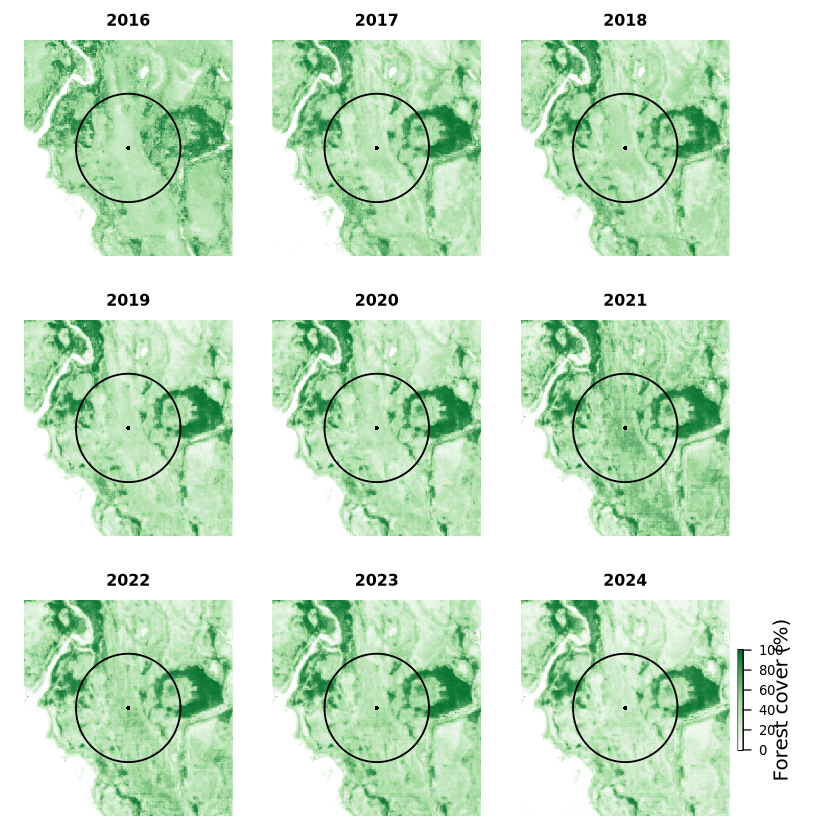

In [18]:
library(fields)

years <- as.integer(py_to_r(ds[["time"]]$values))
forest_arr <- py_to_r(ds[["forest"]]$values)
cols <- colorRampPalette(c("white", "#a1d99b", "#006d2c"))(100)

layout(matrix(c(1,2,3,10,
                4,5,6,10,
                7,8,9,10),
              nrow = 3, byrow = TRUE),
       widths = c(1, 1, 1, 0.38))   # wider legend column

for(i in seq_along(years)) {
  par(mar = c(1.5, 1.5, 2.5, 1))

  forest_mat <- forest_arr[i,,] * (100 / 255)
  forest_mat_sorted <- forest_mat[iy, ix]

  image(
    x_sorted,
    y_sorted,
    t(forest_mat_sorted),
    col = cols,
    zlim = c(0, 100),
    axes = FALSE,
    xlab = "",
    ylab = "",
    main = years[i],
    useRaster = TRUE
  )

  lines(x0 + 500*cos(theta), y0 + 500*sin(theta), lwd = 1.5)
  points(x0, y0, pch = 16, cex = 0.7)
}

par(mar = c(3, 1, 3, 5))
fields::image.plot(
  legend.only = TRUE,
  zlim = c(0, 100),
  col = cols,
  #col = hcl.colors(100, "YlGn"),
  legend.lab = "Forest cover (%)",
  smallplot = c(0.97, 0.99, 0.32, 0.68)
  #smallplot = c(0.88, 0.90, 0.35, 0.65)
  #legend.width = 1.2,
  #legend.mar = 4
)

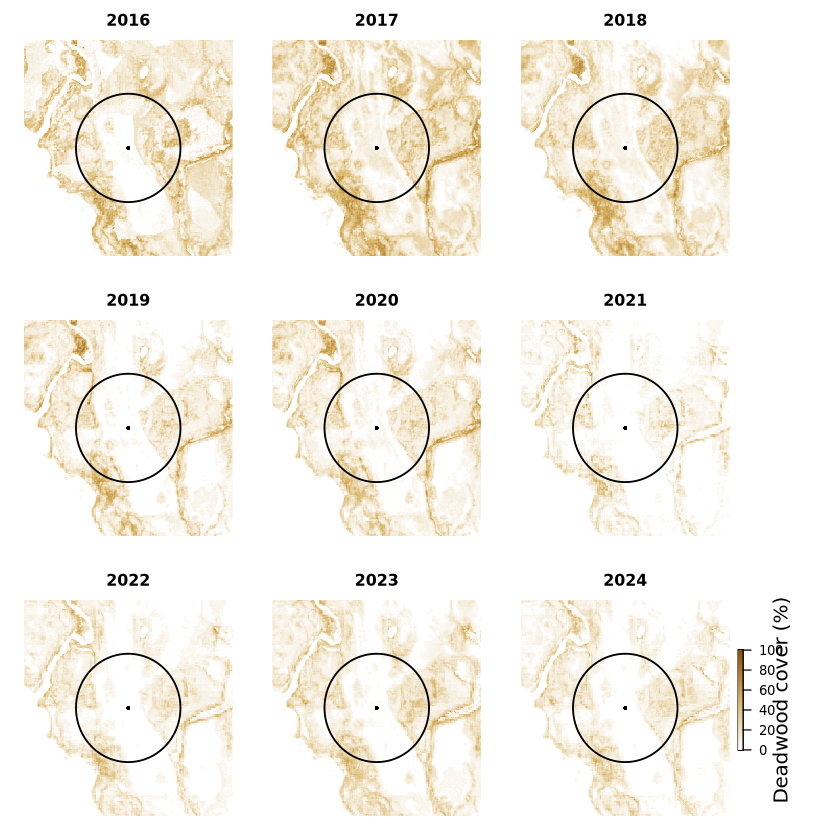

In [19]:
years <- as.integer(py_to_r(ds[["time"]]$values))
deadwood_arr <- py_to_r(ds[["deadwood"]]$values)

# deadwood colors: low = white, high = dark brown
cols_dw <- colorRampPalette(c("white", "#d8b365", "#8c510a"))(100)

layout(matrix(c(1,2,3,10,
                4,5,6,10,
                7,8,9,10),
              nrow = 3, byrow = TRUE),
       widths = c(1, 1, 1, 0.38))

for(i in seq_along(years)) {
  par(mar = c(1.5, 1.5, 2.5, 1))

  deadwood_mat <- deadwood_arr[i,,] * (100 / 255)
  deadwood_mat_sorted <- deadwood_mat[iy, ix]

  image(
    x_sorted,
    y_sorted,
    t(deadwood_mat_sorted),
    col = cols_dw,
    zlim = c(0, 100),
    axes = FALSE,
    xlab = "",
    ylab = "",
    main = years[i],
    useRaster = TRUE
  )

  lines(x0 + 500*cos(theta), y0 + 500*sin(theta), lwd = 1.5)
  points(x0, y0, pch = 16, cex = 0.7)
}

par(mar = c(3, 1, 3, 5))
fields::image.plot(
  legend.only = TRUE,
  zlim = c(0, 100),
  col = cols_dw,
  legend.lab = "Deadwood cover (%)",
  smallplot = c(0.97, 0.99, 0.32, 0.68)
)

In [18]:
plot_df$forest_pct <- as.numeric(as.vector(forest_mat))

In [20]:
ggplot

function (data = NULL, mapping = aes(), ..., environment = parent.frame()) 
{
    UseMethod("ggplot")
}
<bytecode: 0x57d0c3f5f9e8>
<environment: namespace:ggplot2>

In [21]:
str(plot_df)

'data.frame':	40000 obs. of  3 variables:
 $ x         : num  735078 735088 735098 735108 735118 ...
 $ y         : num  6295292 6295292 6295292 6295292 6295292 ...
 $ forest_pct: num  12.16 11.37 0 8.24 14.9 ...
 - attr(*, "out.attrs")=List of 2
  ..$ dim     : Named int [1:2] 200 200
  .. ..- attr(*, "names")= chr [1:2] "x" "y"
  ..$ dimnames:List of 2
  .. ..$ x: chr [1:200] "x=735078.4" "x=735088.4" "x=735098.4" "x=735108.4" ...
  .. ..$ y: chr [1:200] "y=6295292" "y=6295282" "y=6295272" "y=6295262" ...


In [50]:
#### Now I can combine the forestcover loss with the onld one
library(data.table)
deadwood500m <-fread("derived_tables/forest_deadwood_500m_by_site_year10Feb26.csv")

In [51]:
forestcoverloss <- fread("derived_tables/forest_loss_threshold20_500m_by_site_year.csv")

In [52]:
## merge the two tables on site_id and year
deadwood500m_forestcoverloss <- merge(deadwood500m, forestcoverloss, by = c("site_id", "year"))



In [53]:
View(deadwood500m_forestcoverloss)

site_id,year,forest_mean_pct_500m.x,deadwood_mean_pct_500m,forest_mean_pct_500m.y,loss_area_frac_500m,loss_mean_pp_500m,loss_sum_pp_500m
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AR-SLu,2016,0.2881305,0.50062370,0.2881305,NA,NA,NA
AR-SLu,2017,12.3927059,0.79249614,12.3927057,0.0000000000,0.000000000,0.00000
AR-SLu,2018,9.4717855,0.10507409,9.4717857,0.0000000000,0.000000000,0.00000
AR-SLu,2019,4.8412414,0.34605598,4.8412413,0.0001272265,0.002793993,21.96078
AR-SLu,2020,4.9443693,0.08756174,4.9443696,0.0000000000,0.000000000,0.00000
AR-SLu,2021,7.9149828,0.33986929,7.9149828,0.0000000000,0.000000000,0.00000
AR-SLu,2022,3.8991172,0.07174575,3.8991169,0.0000000000,0.000000000,0.00000
AR-SLu,2023,4.3549371,0.40198573,4.3549369,0.0000000000,0.000000000,0.00000
AR-SLu,2024,3.8458815,0.91997206,3.8458814,0.0000000000,0.000000000,0.00000


In [54]:
fwrite(deadwood500m_forestcoverloss, "derived_tables/deadwood_forestcover_lossthreshhold20_500m_by_site_year_11Mar26.csv")

In [9]:
library(data.table)

# =========================================================
# STEP 8c: Merge disturbance (forest + deadwood) into model data
# =========================================================

# ---------------------------------------------------------
# 1) Load model datasets
# ---------------------------------------------------------

dt_all  <- fread("derived_tables/modelready_with_anomalies_gscenter_meteolags_all_years_clean.csv")
dt_2yr  <- fread("derived_tables/modeldata_2yr_with_meteolags_clean.csv")
dt_3yr  <- fread("derived_tables/modeldata_3yr_with_meteolags_clean.csv")

cat("Loaded model datasets:\n")
cat("All years:", dim(dt_all)[1], "rows\n")
cat("2-year   :", dim(dt_2yr)[1], "rows\n")
cat("3-year   :", dim(dt_3yr)[1], "rows\n")

# ---------------------------------------------------------
# 2) Load disturbance table
# ---------------------------------------------------------

disturbance_dt <- as.data.table(final_disturbance_df)

# rename to match model table
setnames(disturbance_dt, "site_id", "SITE_ID")

cat("\nDisturbance table:\n")
print(dim(disturbance_dt))

# ---------------------------------------------------------
# 3) Remove OLD forest/deadwood columns (important!)
# ---------------------------------------------------------

old_disturbance_patterns <- c(
  "forest_mean_pct_500m",
  "deadwood_mean_pct_500m",
  "loss_"
)

remove_old_cols <- function(dt) {
  cols_to_remove <- names(dt)[
    grepl(paste(old_disturbance_patterns, collapse = "|"), names(dt))
  ]
  
  if (length(cols_to_remove) > 0) {
    dt[, (cols_to_remove) := NULL]
  }
  
  return(dt)
}

dt_all <- remove_old_cols(dt_all)
dt_2yr <- remove_old_cols(dt_2yr)
dt_3yr <- remove_old_cols(dt_3yr)

# ---------------------------------------------------------
# 4) Merge disturbance data
# ---------------------------------------------------------

setkey(dt_all, SITE_ID, year)
setkey(dt_2yr, SITE_ID, year)
setkey(dt_3yr, SITE_ID, year)
setkey(disturbance_dt, SITE_ID, year)

dt_all <- merge(dt_all, disturbance_dt, all.x = TRUE)
dt_2yr <- merge(dt_2yr, disturbance_dt, all.x = TRUE)
dt_3yr <- merge(dt_3yr, disturbance_dt, all.x = TRUE)

# ---------------------------------------------------------
# 5) Quick checks
# ---------------------------------------------------------

cat("\nAfter merge:\n")

cat("\nAll years:", dim(dt_all)[1], "rows x", dim(dt_all)[2], "cols\n")
cat("Missing disturbance rows:",
    dt_all[is.na(forest_mean_pct_500m), .N], "\n")

cat("\n2-year:", dim(dt_2yr)[1], "rows x", dim(dt_2yr)[2], "cols\n")
cat("Missing disturbance rows:",
    dt_2yr[is.na(forest_mean_pct_500m), .N], "\n")

cat("\n3-year:", dim(dt_3yr)[1], "rows x", dim(dt_3yr)[2], "cols\n")
cat("Missing disturbance rows:",
    dt_3yr[is.na(forest_mean_pct_500m), .N], "\n")

# ---------------------------------------------------------
# 6) Save final modelling datasets
# ---------------------------------------------------------

fwrite(dt_all, "derived_tables/modelready_FINAL_all_years.csv")
fwrite(dt_2yr, "derived_tables/modelready_FINAL_2yr.csv")
fwrite(dt_3yr, "derived_tables/modelready_FINAL_3yr.csv")

cat("\nFiles written:\n")
cat("- derived_tables/modelready_FINAL_all_years.csv\n")
cat("- derived_tables/modelready_FINAL_2yr.csv\n")
cat("- derived_tables/modelready_FINAL_3yr.csv\n")


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




Loaded model datasets:
All years: 1689 rows
2-year   : 678 rows
3-year   : 656 rows

Disturbance table:
[1] 3245   10

After merge:

All years: 1689 rows x 500 cols
Missing disturbance rows: 1041 

2-year: 678 rows x 500 cols
Missing disturbance rows: 46 

3-year: 656 rows x 500 cols
Missing disturbance rows: 42 

Files written:
- derived_tables/modelready_FINAL_all_years.csv
- derived_tables/modelready_FINAL_2yr.csv
- derived_tables/modelready_FINAL_3yr.csv


In [10]:
library(data.table)

# =========================================================
# STEP 8d: Diagnose disturbance coverage after merge
# =========================================================

dt_all <- fread("derived_tables/modelready_FINAL_all_years.csv")
dt_2yr <- fread("derived_tables/modelready_FINAL_2yr.csv")
dt_3yr <- fread("derived_tables/modelready_FINAL_3yr.csv")

dist_cols <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m",
  "loss_mean_pp_500m",
  "loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

dist_cols <- dist_cols[dist_cols %in% names(dt_all)]

cat("Disturbance columns found:\n")
print(dist_cols)

# ---------------------------------------------------------
# 1) Missing rows summary
# ---------------------------------------------------------

cat("\nMissing rows based on forest_mean_pct_500m:\n")
cat("All years:", dt_all[is.na(forest_mean_pct_500m), .N], "\n")
cat("2-year   :", dt_2yr[is.na(forest_mean_pct_500m), .N], "\n")
cat("3-year   :", dt_3yr[is.na(forest_mean_pct_500m), .N], "\n")

# ---------------------------------------------------------
# 2) Missing by site
# ---------------------------------------------------------

missing_by_site_all <- dt_all[is.na(forest_mean_pct_500m), .N, by = SITE_ID][order(-N)]
missing_by_site_2yr <- dt_2yr[is.na(forest_mean_pct_500m), .N, by = SITE_ID][order(-N)]
missing_by_site_3yr <- dt_3yr[is.na(forest_mean_pct_500m), .N, by = SITE_ID][order(-N)]

cat("\nTop sites with missing disturbance rows (all years):\n")
print(missing_by_site_all[1:20])

cat("\nTop sites with missing disturbance rows (2-year):\n")
print(missing_by_site_2yr[1:20])

cat("\nTop sites with missing disturbance rows (3-year):\n")
print(missing_by_site_3yr[1:20])

# ---------------------------------------------------------
# 3) Missing by year
# ---------------------------------------------------------

missing_by_year_all <- dt_all[is.na(forest_mean_pct_500m), .N, by = year][order(year)]
missing_by_year_2yr <- dt_2yr[is.na(forest_mean_pct_500m), .N, by = year][order(year)]
missing_by_year_3yr <- dt_3yr[is.na(forest_mean_pct_500m), .N, by = year][order(year)]

cat("\nMissing disturbance rows by year (all years):\n")
print(missing_by_year_all)

cat("\nMissing disturbance rows by year (2-year):\n")
print(missing_by_year_2yr)

cat("\nMissing disturbance rows by year (3-year):\n")
print(missing_by_year_3yr)

# ---------------------------------------------------------
# 4) Save exact missing rows for inspection
# ---------------------------------------------------------

missing_rows_all <- dt_all[is.na(forest_mean_pct_500m), .(SITE_ID, year)]
missing_rows_2yr <- dt_2yr[is.na(forest_mean_pct_500m), .(SITE_ID, year)]
missing_rows_3yr <- dt_3yr[is.na(forest_mean_pct_500m), .(SITE_ID, year)]

fwrite(missing_rows_all, "derived_tables/disturbance_missing_rows_all_years.csv")
fwrite(missing_rows_2yr, "derived_tables/disturbance_missing_rows_2yr.csv")
fwrite(missing_rows_3yr, "derived_tables/disturbance_missing_rows_3yr.csv")

cat("\nFiles written:\n")
cat("- derived_tables/disturbance_missing_rows_all_years.csv\n")
cat("- derived_tables/disturbance_missing_rows_2yr.csv\n")
cat("- derived_tables/disturbance_missing_rows_3yr.csv\n")

Disturbance columns found:
[1] "forest_mean_pct_500m"             "loss_area_frac_500m"             
[3] "loss_mean_pp_500m"                "loss_sum_pp_500m"                
[5] "deadwood_mean_pct_500m"           "deadwood_increase_area_frac_500m"
[7] "deadwood_increase_mean_pp_500m"   "deadwood_increase_sum_pp_500m"   

Missing rows based on forest_mean_pct_500m:
All years: 1041 
2-year   : 46 
3-year   : 42 

Top sites with missing disturbance rows (all years):
    SITE_ID     N
     <char> <int>
 1:  CA-Cbo    21
 2:  DK-Sor    21
 3:  IT-Col    19
 4:  RU-Fyo    18
 5:  US-NR1    18
 6:  IL-Yat    17
 7:  IT-Ren    17
 8:  US-SP1    17
 9:  US-Ton    16
10:  CA-Oas    15
11:  US-Me2    15
12:  CA-Man    14
13:  CA-TP3    14
14:  IT-SRo    14
15:  US-Ho2    14
16:  CA-TP4    13
17:  FR-LBr    13
18:  IT-Lav    13
19:  US-Bar    13
20:  US-MOz    13
    SITE_ID     N
     <char> <int>

Top sites with missing disturbance rows (2-year):
    SITE_ID     N
     <char> <int>
 1:  BR-Npw 

In [13]:
library(data.table)

# =========================================================
# STEP 8e: Filter to forest ecosystems only
# =========================================================

# ---------------------------------------------------------
# 1) Load datasets
# ---------------------------------------------------------

dt_all <- fread("derived_tables/modelready_FINAL_all_years.csv")
dt_2yr <- fread("derived_tables/modelready_FINAL_2yr.csv")
dt_3yr <- fread("derived_tables/modelready_FINAL_3yr.csv")

cat("Before filtering:\n")
cat("All years:", nrow(dt_all), "rows\n")
cat("2-year   :", nrow(dt_2yr), "rows\n")
cat("3-year   :", nrow(dt_3yr), "rows\n")

# ---------------------------------------------------------
# 2) Define NON-forest classes to remove
# ---------------------------------------------------------

non_forest_classes <- c(
  "CRO",  # cropland
  "GRA",  # grassland
  "SNO",  # snow/ice
  "BSV",   # barren/sparse vegetation
  "CVM"
)

# optional: uncomment if needed
# non_forest_classes <- c(non_forest_classes, "SAV", "WSA")

# ---------------------------------------------------------
# 3) Filter datasets
# ---------------------------------------------------------

dt_all_forest <- dt_all[!IGBP %in% non_forest_classes]
dt_2yr_forest <- dt_2yr[!IGBP %in% non_forest_classes]
dt_3yr_forest <- dt_3yr[!IGBP %in% non_forest_classes]

# ---------------------------------------------------------
# 4) Print summary
# ---------------------------------------------------------

cat("\nAfter filtering:\n")

cat("\nAll years:\n")
cat("Rows :", nrow(dt_all_forest), "\n")
cat("Sites:", uniqueN(dt_all_forest$SITE_ID), "\n")

cat("\n2-year:\n")
cat("Rows :", nrow(dt_2yr_forest), "\n")
cat("Sites:", uniqueN(dt_2yr_forest$SITE_ID), "\n")

cat("\n3-year:\n")
cat("Rows :", nrow(dt_3yr_forest), "\n")
cat("Sites:", uniqueN(dt_3yr_forest$SITE_ID), "\n")

# ---------------------------------------------------------
# 5) Check missing disturbance again
# ---------------------------------------------------------

cat("\nMissing disturbance AFTER filtering:\n")

cat("All years:", dt_all_forest[is.na(forest_mean_pct_500m), .N], "\n")
cat("2-year   :", dt_2yr_forest[is.na(forest_mean_pct_500m), .N], "\n")
cat("3-year   :", dt_3yr_forest[is.na(forest_mean_pct_500m), .N], "\n")

# ---------------------------------------------------------
# 6) Save final modeling datasets
# ---------------------------------------------------------

fwrite(dt_all_forest, "derived_tables/modelready_FINAL_all_years_FOREST.csv")
fwrite(dt_2yr_forest, "derived_tables/modelready_FINAL_2yr_FOREST.csv")
fwrite(dt_3yr_forest, "derived_tables/modelready_FINAL_3yr_FOREST.csv")

cat("\nFiles written:\n")
cat("- derived_tables/modelready_FINAL_all_years_FOREST.csv\n")
cat("- derived_tables/modelready_FINAL_2yr_FOREST.csv\n")
cat("- derived_tables/modelready_FINAL_3yr_FOREST.csv\n")

Before filtering:
All years: 1689 rows
2-year   : 678 rows
3-year   : 656 rows

After filtering:

All years:
Rows : 1667 
Sites: 233 

2-year:
Rows : 657 
Sites: 115 

3-year:
Rows : 635 
Sites: 104 

Missing disturbance AFTER filtering:
All years: 1039 
2-year   : 45 
3-year   : 41 

Files written:
- derived_tables/modelready_FINAL_all_years_FOREST.csv
- derived_tables/modelready_FINAL_2yr_FOREST.csv
- derived_tables/modelready_FINAL_3yr_FOREST.csv


In [12]:
library(data.table)

dt <- fread("derived_tables/modelready_FINAL_all_years.csv")

cat("Unique IGBP classes:\n")
print(sort(unique(dt$IGBP)))

cat("\nCounts per IGBP:\n")
print(dt[, .N, by = IGBP][order(-N)])

Unique IGBP classes:
 [1] "CSH" "CVM" "DBF" "DNF" "EBF" "ENF" "MF"  "OSH" "SAV" "WET" "WSA"

Counts per IGBP:
      IGBP     N
    <char> <int>
 1:    ENF   575
 2:    DBF   303
 3:    WET   246
 4:    OSH   214
 5:    EBF    75
 6:    SAV    75
 7:    WSA    66
 8:     MF    56
 9:    CSH    40
10:    CVM    22
11:    DNF    17


In [14]:
### run for different buffer size for 52 sites
library(data.table)

dt_master <- fread("derived_tables/modeldata_MASTER_complete_3yr_lag24_anomlag12.csv")

final_sites <- unique(dt_master$SITE_ID)

length(final_sites)   # should be 52


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last




[1] 52

In [15]:
library(stringr)

get_site_id <- function(zpath) {
  str_replace(basename(zpath), "_inference\\.zarr$", "")
}

zarr_site_ids <- vapply(zarr_paths, get_site_id, character(1))

zarr_paths_52 <- zarr_paths[zarr_site_ids %in% final_sites]

length(zarr_paths_52)   # should also be 52

[1] 52

In [16]:
### different buffer sizes
library(dplyr)
library(stringr)
library(data.table)

get_site_id <- function(zpath) {
  str_replace(basename(zpath), "_inference\\.zarr$", "")
}

# radii in meters
buffer_radii <- c(100, 200, 300, 400, 500)

# optional: resume from previous checkpoint if it exists
if (file.exists("checkpoint_workspace_52sites.RData")) {
  load("checkpoint_workspace_52sites.RData")
  message("Loaded existing checkpoint workspace.")
} else {
  all_results <- list()
  failed_sites <- character()
}

# skip already processed sites
done_sites <- names(all_results)
zarr_paths_52_run <- zarr_paths_52[
  !(vapply(zarr_paths_52, get_site_id, character(1)) %in% done_sites)
]

message("Sites already done: ", length(done_sites))
message("Sites left to run: ", length(zarr_paths_52_run))

for (zpath in zarr_paths_52_run) {
  
  site_id <- get_site_id(zpath)
  message("Processing ", site_id)
  
  res <- tryCatch({
    
    ds <- xr$open_zarr(zpath, consolidated = FALSE)
    
    years <- as.integer(py_to_r(ds[["time"]]$values))
    x <- as.vector(py_to_r(ds[["x"]]$values))
    y <- as.vector(py_to_r(ds[["y"]]$values))
    
    # ------------------------------------------------------
    # Build distance grid from cube center
    # ------------------------------------------------------
    
    x0 <- mean(range(x))
    y0 <- mean(range(y))
    dist2 <- outer((y - y0)^2, (x - x0)^2, "+")
    
    # one mask per radius
    mask_list <- lapply(buffer_radii, function(r) dist2 <= (r^2))
    names(mask_list) <- paste0(buffer_radii, "m")
    
    # ------------------------------------------------------
    # Load forest and deadwood arrays and convert to %
    # expected dimensions: [time, y, x]
    # ------------------------------------------------------
    
    forest_arr <- py_to_r(ds[["forest"]]$values)
    forest_arr <- array(as.numeric(forest_arr) * (100 / 255), dim = dim(forest_arr))
    
    deadwood_arr <- py_to_r(ds[["deadwood"]]$values)
    deadwood_arr <- array(as.numeric(deadwood_arr) * (100 / 255), dim = dim(deadwood_arr))
    
    out_list <- vector("list", length(years))
    
    for (i in seq_along(years)) {
      
      forest_now <- forest_arr[i, , ]
      deadwood_now <- deadwood_arr[i, , ]
      
      row_out <- list(
        site_id = site_id,
        year = years[i]
      )
      
      if (i > 1) {
        forest_prev <- forest_arr[i - 1, , ]
        deadwood_prev <- deadwood_arr[i - 1, , ]
        
        # year-to-year changes
        forest_delta <- forest_now - forest_prev
        deadwood_delta <- deadwood_now - deadwood_prev
        
        # thresholded changes
        # FOREST: keep only drops <= -20 pp, convert to positive magnitude
        loss_pp <- ifelse(forest_delta <= -20, -forest_delta, 0)
        
        # DEADWOOD: keep only increases >= 20 pp
        deadwood_gain_pp <- ifelse(deadwood_delta >= 20, deadwood_delta, 0)
      }
      
      # ----------------------------------------------------
      # Calculate metrics for each buffer radius
      # ----------------------------------------------------
      
      for (r in buffer_radii) {
        
        rlab <- paste0(r, "m")
        mask <- mask_list[[rlab]]
        
        # mean state
        row_out[[paste0("forest_mean_pct_", rlab)]] <- mean(forest_now[mask], na.rm = TRUE)
        row_out[[paste0("deadwood_mean_pct_", rlab)]] <- mean(deadwood_now[mask], na.rm = TRUE)
        
        if (i == 1) {
          # no previous year available
          row_out[[paste0("loss_area_frac_", rlab)]] <- NA_real_
          row_out[[paste0("loss_mean_pp_", rlab)]]   <- NA_real_
          row_out[[paste0("loss_sum_pp_", rlab)]]    <- NA_real_
          
          row_out[[paste0("deadwood_increase_area_frac_", rlab)]] <- NA_real_
          row_out[[paste0("deadwood_increase_mean_pp_", rlab)]]   <- NA_real_
          row_out[[paste0("deadwood_increase_sum_pp_", rlab)]]    <- NA_real_
          
        } else {
          masked_loss <- loss_pp[mask]
          masked_deadwood_gain <- deadwood_gain_pp[mask]
          
          # forest loss metrics
          row_out[[paste0("loss_area_frac_", rlab)]] <- mean(masked_loss > 0, na.rm = TRUE)
          row_out[[paste0("loss_mean_pp_", rlab)]]   <- mean(masked_loss, na.rm = TRUE)
          row_out[[paste0("loss_sum_pp_", rlab)]]    <- sum(masked_loss, na.rm = TRUE)
          
          # deadwood increase metrics
          row_out[[paste0("deadwood_increase_area_frac_", rlab)]] <- mean(masked_deadwood_gain > 0, na.rm = TRUE)
          row_out[[paste0("deadwood_increase_mean_pp_", rlab)]]   <- mean(masked_deadwood_gain, na.rm = TRUE)
          row_out[[paste0("deadwood_increase_sum_pp_", rlab)]]    <- sum(masked_deadwood_gain, na.rm = TRUE)
        }
      }
      
      out_list[[i]] <- as.data.frame(row_out, check.names = FALSE)
    }
    
    bind_rows(out_list)
    
  }, error = function(e) {
    message("Failed for ", site_id, ": ", conditionMessage(e))
    failed_sites <<- unique(c(failed_sites, site_id))
    return(NULL)
  })
  
  # --------------------------------------------------------
  # Save after each successfully finished site
  # --------------------------------------------------------
  
  if (!is.null(res) && nrow(res) > 0) {
    
    all_results[[site_id]] <- res
    
    partial_df <- bind_rows(all_results)
    fwrite(partial_df, "checkpoint_disturbance_52sites.csv")
    
    writeLines(failed_sites, "failed_sites_52sites.txt")
    
    save.image("checkpoint_workspace_52sites.RData")
    
    message("Checkpoint saved after site ", site_id)
  }
}

# final combined output
final_disturbance_df <- bind_rows(all_results)

fwrite(final_disturbance_df, "final_disturbance_52sites_multibuffer.csv")
writeLines(failed_sites, "failed_sites_52sites.txt")
save.image("final_workspace_52sites_multibuffer.RData")

message("Done.")
message("Final rows: ", nrow(final_disturbance_df))
message("Final sites: ", uniqueN(final_disturbance_df$site_id))
message("Failed sites: ", length(failed_sites))

Sites already done: 0

Sites left to run: 52

Processing AU-Boy

Checkpoint saved after site AU-Boy

Processing AU-GWW

Checkpoint saved after site AU-GWW

Processing AU-War

Checkpoint saved after site AU-War

Processing AU-Whr

Checkpoint saved after site AU-Whr

Processing AU-Wom

Checkpoint saved after site AU-Wom

Processing CA-Cbo

Checkpoint saved after site CA-Cbo

Processing CA-EM1

Checkpoint saved after site CA-EM1

Processing CA-TPD

Checkpoint saved after site CA-TPD

Processing CL-SDF

Checkpoint saved after site CL-SDF

Processing CZ-RAJ

Checkpoint saved after site CZ-RAJ

Processing CZ-Stn

Checkpoint saved after site CZ-Stn

Processing DE-Akm

Checkpoint saved after site DE-Akm

Processing DE-Hte

Checkpoint saved after site DE-Hte

Processing DK-Sor

Checkpoint saved after site DK-Sor

Processing FI-Sii

Checkpoint saved after site FI-Sii

Processing IT-Lav

Checkpoint saved after site IT-Lav

Processing IT-Ren

Checkpoint saved after site IT-Ren

Processing IT-TrF



Combine it with the model dataset


In [20]:
library(data.table)

dt_model <- fread("derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_used.csv")
dist_dt   <- fread("final_disturbance_52sites_multibuffer.csv")

setnames(dist_dt, "site_id", "SITE_ID")

# remove old single-buffer disturbance columns before merge
old_disturbance_cols <- c(
  "forest_mean_pct_500m",
  "loss_area_frac_500m",
  "loss_mean_pp_500m",
  "loss_sum_pp_500m",
  "deadwood_mean_pct_500m",
  "deadwood_increase_area_frac_500m",
  "deadwood_increase_mean_pp_500m",
  "deadwood_increase_sum_pp_500m"
)

old_disturbance_cols <- old_disturbance_cols[old_disturbance_cols %in% names(dt_model)]

dt_model[, (old_disturbance_cols) := NULL]

dt_merged <- merge(
  dt_model,
  dist_dt,
  by = c("SITE_ID", "year"),
  all.x = TRUE
)

In [21]:
View(dt_merged)

SITE_ID,year,uWUE,ETmax,GPPsat,NEPmax,uWUE_anom,ETmax_anom,GPPsat_anom,NEPmax_anom,⋯,deadwood_increase_mean_pp_400m,deadwood_increase_sum_pp_400m,forest_mean_pct_500m,deadwood_mean_pct_500m,loss_area_frac_500m,loss_mean_pp_500m,loss_sum_pp_500m,deadwood_increase_area_frac_500m,deadwood_increase_mean_pp_500m,deadwood_increase_sum_pp_500m
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AU-Boy,2020,1.4732505,0.08067205,11.650058,12.939085,0.363430158,-2.249485e-02,0.32345843,0.10834250,⋯,0.012957412,65.09804,8.829367,2.40682533,0.0304071247,0.739909195,5815.68627,0.0039440204,0.101731278,799.60784
AU-Boy,2021,1.2432836,0.11402598,13.116585,15.571685,0.133463273,1.085908e-02,1.78998495,2.74094250,⋯,0.041291995,207.45098,10.812703,3.15611435,0.0001272265,0.002544529,20.00000,0.0019083969,0.043755925,343.92157
AU-Boy,2022,1.3295602,0.11021342,15.150562,16.432452,0.219739907,7.046520e-03,3.82396185,3.60170950,⋯,0.022792557,114.50980,22.552462,4.34101681,0.0000000000,0.000000000,0.00000,0.0011450382,0.026991967,212.15686
AU-GWW,2018,0.7405456,0.08910414,4.519760,5.610664,-0.354740557,1.395966e-02,-0.83837478,-1.07412727,⋯,0.000000000,0.00000,19.548471,5.07139650,0.0001272265,0.002943671,23.13725,0.0000000000,0.000000000,0.00000
AU-GWW,2019,0.9367222,0.06960913,5.596712,7.649744,-0.158563924,-5.535355e-03,0.23857706,0.96495273,⋯,0.000000000,0.00000,19.536447,5.35618420,0.0000000000,0.000000000,0.00000,0.0000000000,0.000000000,0.00000
AU-GWW,2020,1.6981964,0.07193393,6.768517,9.064633,0.602910277,-3.210557e-03,1.41038219,2.37984213,⋯,0.000000000,0.00000,21.112857,4.41605548,0.0000000000,0.000000000,0.00000,0.0000000000,0.000000000,0.00000
AU-GWW,2021,1.7050668,0.06961746,7.239614,8.848136,0.609780674,-5.527029e-03,1.88147899,2.16334433,⋯,0.000000000,0.00000,20.088011,3.15825974,0.0000000000,0.000000000,0.00000,0.0000000000,0.000000000,0.00000
AU-GWW,2022,2.3811295,0.05308200,7.418736,9.571864,1.285843342,-2.206248e-02,2.06060059,2.88707283,⋯,0.000000000,0.00000,18.330440,3.62824926,0.0000000000,0.000000000,0.00000,0.0002544529,0.005637879,44.31373
AU-War,2018,0.9788182,0.29520910,40.147739,38.539140,-0.505238899,7.792021e-02,3.05484693,3.37083789,⋯,8.491007868,42658.82353,59.933992,17.53784364,0.0000000000,0.000000000,0.00000,0.2875318066,9.469789952,74432.54902


In [18]:
library(data.table)

disturbance_base_patterns <- c(
  "^forest_mean_pct_",
  "^loss_area_frac_",
  "^loss_mean_pp_",
  "^loss_sum_pp_",
  "^deadwood_mean_pct_",
  "^deadwood_increase_area_frac_",
  "^deadwood_increase_mean_pp_",
  "^deadwood_increase_sum_pp_"
)

is_disturbance_dup_x <- sapply(names(dt_merged), function(nm) {
  grepl("\\.x$", nm) && any(sapply(disturbance_base_patterns, function(p) grepl(p, nm)))
})

is_disturbance_dup_y <- sapply(names(dt_merged), function(nm) {
  grepl("\\.y$", nm) && any(sapply(disturbance_base_patterns, function(p) grepl(p, nm)))
})

dup_x <- names(dt_merged)[is_disturbance_dup_x]
dup_y <- names(dt_merged)[is_disturbance_dup_y]

dt_merged[, (dup_x) := NULL]
setnames(dt_merged, old = dup_y, new = sub("\\.y$", "", dup_y))

In [22]:
dt_merged <- fread("derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer.csv")

In [25]:
names(dt_merged)

[1] "SITE_ID"                            "year"                              
  [3] "uWUE"                               "ETmax"                             
  [5] "GPPsat"                             "NEPmax"                            
  [7] "uWUE_anom"                          "ETmax_anom"                        
  [9] "GPPsat_anom"                        "NEPmax_anom"                       
 [11] "P_mean_lag01"                       "P_mean_lag02"                      
 [13] "P_mean_lag03"                       "P_mean_lag04"                      
 [15] "P_mean_lag05"                       "P_mean_lag06"                      
 [17] "P_mean_lag07"                       "P_mean_lag08"                      
 [19] "P_mean_lag09"                       "P_mean_lag10"                      
 [21] "P_mean_lag11"                       "P_mean_lag12"                      
 [23] "P_mean_lag13"                       "P_mean_lag14"                      
 [25] "P_mean_lag15"                       "P_mean_lag16"                      
 [27] "P_mean_lag17"                       "P_mean_lag18"                      
 [29] "P_mean_lag19"                       "P_mean_lag20"                      
 [31] "P_mean_lag21"                       "P_mean_lag22"                      
 [33] "P_mean_lag23"                       "P_mean_lag24"                      
 [35] "P_q10_lag01"                        "P_q10_lag02"                       
 [37] "P_q10_lag03"                        "P_q10_lag04"                       
 [39] "P_q10_lag05"                        "P_q10_lag06"                       
 [41] "P_q10_lag07"                        "P_q10_lag08"                       
 [43] "P_q10_lag09"                        "P_q10_lag10"                       
 [45] "P_q10_lag11"                        "P_q10_lag12"                       
 [47] "P_q10_lag13"                        "P_q10_lag14"                       
 [49] "P_q10_lag15"                        "P_q10_lag16"                       
 [51] "P_q10_lag17"                        "P_q10_lag18"                       
 [53] "P_q10_lag19"                        "P_q10_lag20"                       
 [55] "P_q10_lag21"                        "P_q10_lag22"                       
 [57] "P_q10_lag23"                        "P_q10_lag24"                       
 [59] "P_q90_lag01"                        "P_q90_lag02"                       
 [61] "P_q90_lag03"                        "P_q90_lag04"                       
 [63] "P_q90_lag05"                        "P_q90_lag06"                       
 [65] "P_q90_lag07"                        "P_q90_lag08"                       
 [67] "P_q90_lag09"                        "P_q90_lag10"                       
 [69] "P_q90_lag11"                        "P_q90_lag12"                       
 [71] "P_q90_lag13"                        "P_q90_lag14"                       
 [73] "P_q90_lag15"                        "P_q90_lag16"                       
 [75] "P_q90_lag17"                        "P_q90_lag18"                       
 [77] "P_q90_lag19"                        "P_q90_lag20"                       
 [79] "P_q90_lag21"                        "P_q90_lag22"                       
 [81] "P_q90_lag23"                        "P_q90_lag24"                       
 [83] "SW_mean_lag01"                      "SW_mean_lag02"                     
 [85] "SW_mean_lag03"                      "SW_mean_lag04"                     
 [87] "SW_mean_lag05"                      "SW_mean_lag06"                     
 [89] "SW_mean_lag07"                      "SW_mean_lag08"                     
 [91] "SW_mean_lag09"                      "SW_mean_lag10"                     
 [93] "SW_mean_lag11"                      "SW_mean_lag12"                     
 [95] "SW_mean_lag13"                      "SW_mean_lag14"                     
 [97] "SW_mean_lag15"                      "SW_mean_lag16"                     
 [99] "SW_mean_lag17"                      "SW_mean_lag18"                     
[1

In [26]:
library(data.table)

# ---------------------------------------------------------
# 1) Load the merged multibuffer dataset
# ---------------------------------------------------------

dt_merged <- fread(
  "derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer.csv"
)

cat("Loaded rows:", nrow(dt_merged), "\n")
cat("Loaded cols:", ncol(dt_merged), "\n")

# ---------------------------------------------------------
# 2) Identify duplicated disturbance columns (.x / .y)
# ---------------------------------------------------------

disturbance_base_patterns <- c(
  "^forest_mean_pct_",
  "^loss_area_frac_",
  "^loss_mean_pp_",
  "^loss_sum_pp_",
  "^deadwood_mean_pct_",
  "^deadwood_increase_area_frac_",
  "^deadwood_increase_mean_pp_",
  "^deadwood_increase_sum_pp_"
)

is_disturbance_dup_x <- sapply(names(dt_merged), function(nm) {
  grepl("\\.x$", nm) && any(sapply(disturbance_base_patterns, function(p) grepl(p, nm)))
})

is_disturbance_dup_y <- sapply(names(dt_merged), function(nm) {
  grepl("\\.y$", nm) && any(sapply(disturbance_base_patterns, function(p) grepl(p, nm)))
})

dup_x <- names(dt_merged)[is_disturbance_dup_x]
dup_y <- names(dt_merged)[is_disturbance_dup_y]

cat("Duplicate disturbance .x columns:", length(dup_x), "\n")
cat("Duplicate disturbance .y columns:", length(dup_y), "\n")

# ---------------------------------------------------------
# 3) Drop old .x columns and rename .y back to clean names
# ---------------------------------------------------------

dt_merged[, (dup_x) := NULL]
setnames(dt_merged, old = dup_y, new = sub("\\.y$", "", dup_y))

# ---------------------------------------------------------
# 4) Check result
# ---------------------------------------------------------

cat("Any .x left? ", any(grepl("\\.x$", names(dt_merged))), "\n")
cat("Any .y left? ", any(grepl("\\.y$", names(dt_merged))), "\n")

cat("\n100m vars:\n")
print(grep("_100m$", names(dt_merged), value = TRUE))

cat("\n200m vars:\n")
print(grep("_200m$", names(dt_merged), value = TRUE))

cat("\n300m vars:\n")
print(grep("_300m$", names(dt_merged), value = TRUE))

cat("\n400m vars:\n")
print(grep("_400m$", names(dt_merged), value = TRUE))

cat("\n500m vars:\n")
print(grep("_500m$", names(dt_merged), value = TRUE))

# ---------------------------------------------------------
# 5) Save CLEAN version
# ---------------------------------------------------------

out_file <- "derived_tables/final_results_3yr/modeldata_MASTER_complete_3yr_lag24_anomlag12_multibuffer_clean.csv"

fwrite(dt_merged, out_file)

cat("\nClean file written:\n")
cat(out_file, "\n")

Loaded rows: 156 
Loaded cols: 375 
Duplicate disturbance .x columns: 8 
Duplicate disturbance .y columns: 8 
Any .x left?  FALSE 
Any .y left?  FALSE 

100m vars:
[1] "forest_mean_pct_100m"             "deadwood_mean_pct_100m"          
[3] "loss_area_frac_100m"              "loss_mean_pp_100m"               
[5] "loss_sum_pp_100m"                 "deadwood_increase_area_frac_100m"
[7] "deadwood_increase_mean_pp_100m"   "deadwood_increase_sum_pp_100m"   

200m vars:
[1] "forest_mean_pct_200m"             "deadwood_mean_pct_200m"          
[3] "loss_area_frac_200m"              "loss_mean_pp_200m"               
[5] "loss_sum_pp_200m"                 "deadwood_increase_area_frac_200m"
[7] "deadwood_increase_mean_pp_200m"   "deadwood_increase_sum_pp_200m"   

300m vars:
[1] "forest_mean_pct_300m"             "deadwood_mean_pct_300m"          
[3] "loss_area_frac_300m"              "loss_mean_pp_300m"               
[5] "loss_sum_pp_300m"                 "deadwood_increase_area_frac_300m